In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import networkx as nx
from networkx.algorithms.community import leiden_communities
from adjustText import adjust_text
import gget
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from matplotlib import colormaps

In [ ]:
# nx.config.backend_priority = ["igraph"]

In [14]:
# import igraph
# import leidenalg

In [15]:
# print(nx.__version__)

3.5


# Load in TF-associated networks

In [2]:
# MYOD1
path1 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/MYOD_network_1storder_310.csv"
mdf = pd.read_csv(path1, index_col=0)
print(mdf.shape)
display(mdf.head())


# PRRX1
path2 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/PRRX1_network_1storder_310.csv"
pdf = pd.read_csv(path2, index_col=0)
print(pdf.shape)
display(pdf.head())

(514, 514)


,MYOD1,CD99,KDM1A,PDK4,CALCR,HOXA11,MEOX1,CREBBP,SOX8,IFRD1,...,INS,ENSG00000255071,EID1,SCX,DUX4,PECAM1,MYMX,MYH4,H3-7,DACH1
MYOD1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
CD99,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
KDM1A,1,0,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
PDK4,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
CALCR,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


(174, 174)


,PRRX1,COPZ2,METTL13,DCN,SNAI2,VIM,CDH1,PHF23,FOXC1,SYNE2,...,PAX9,TOP1,BMPR2,COL5A2,POU5F1,TWIST2,BGLAP,FOXD1,SCX,GTF2I
PRRX1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
COPZ2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
METTL13,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
DCN,1,0,0,0,1,1,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0
SNAI2,1,0,0,1,0,1,1,0,1,0,...,0,0,0,1,1,1,0,0,0,0


## Make graphs

In [3]:
# MYOD1
GM = nx.from_pandas_adjacency(mdf, create_using=nx.Graph) # keeps self-loops
GM.remove_edges_from(nx.selfloop_edges(GM)) # remove self-loops

print(f"MYOD1:\nN nodes: {GM.number_of_nodes()}\nN edges: {GM.number_of_edges()}")

# PRRX1
GP = nx.from_pandas_adjacency(pdf, create_using=nx.Graph) # keeps self-loops
GP.remove_edges_from(nx.selfloop_edges(GP)) # remove self-loops

print(f"\nPRRX1:\nN nodes: {GP.number_of_nodes()}\nN edges: {GP.number_of_edges()}")

## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
prrx_nodes = list(GP.nodes())

MYOD1:
N nodes: 514
N edges: 25648

PRRX1:
N nodes: 174
N edges: 3315


# Community detection

## MYOD1

In [7]:
M = GM.copy()

comms = louvain_communities(
    M,
    seed=1,
    resolution=1.1,
)

# comms = leiden_communities(
#     M,
#     seed=1729,
#     resolution=1,
# )

module_of = {n: i for i, comm in enumerate(comms) for n in comm}
nx.set_node_attributes(M, module_of, "module")

print("Nodes:", M.number_of_nodes(), "Edges:", M.number_of_edges())
print("Modules:", len(comms))
print("Module sizes:", sorted([len(c) for c in comms], reverse=True))


Q = modularity(M, comms)
print("Modularity Q:", Q)

Nodes: 514 Edges: 25648
Modules: 5
Module sizes: [151, 144, 122, 89, 8]
Modularity Q: 0.23179506286267673


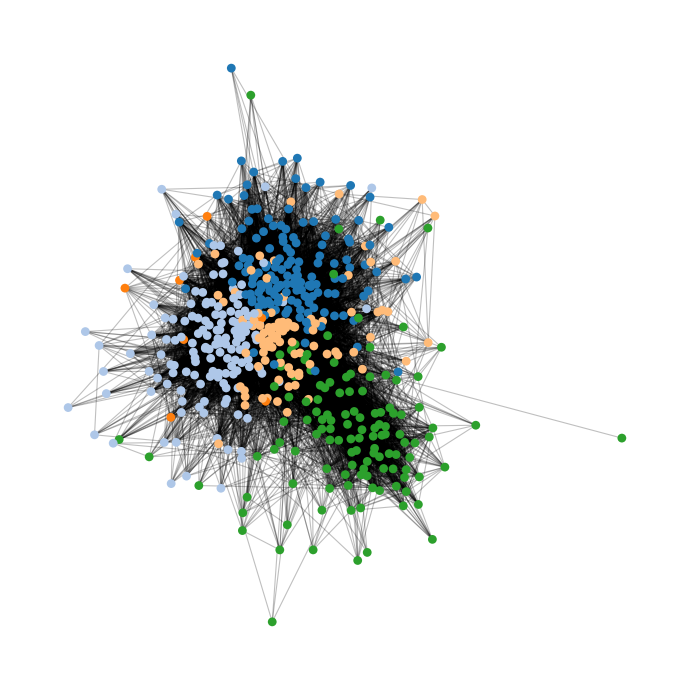

In [8]:
pos = nx.spring_layout(M, seed=1)  # compute once, reuse across panels

cmap = colormaps["tab20"]
node_colors = [cmap(module_of[n] % 20) for n in M.nodes()]

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(M, pos, alpha=0.25, width=0.8)
nx.draw_networkx_nodes(M, pos, node_color=node_colors, node_size=40, linewidths=0)
plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
modules = {i: sorted(list(nodes)) for i, nodes in enumerate(comms)}

# pd.set_option('display.max_colwidth', None)

database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

for module, nodes in modules.items():
    
    print(f"Module {module+1}: {len(nodes)} genes")

    enr = gget.enrichr(
        nodes,
        database,
        save=False,
    )

    enr = enr[enr['adj_p_val'] < 0.05]
    print(enr.columns)

    enr['adj_score'] = abs(np.log(enr['adj_p_val']) * enr['z_score'])
        
    # enr = enr.sort_values(by='adj_score', ascending=False)
    
    display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score', 'adj_score']].head(10))
    
    # break

Fri Apr 17 12:00:22 2026 INFO Performing Enichr analysis using database GO_Biological_Process_2025.


Module 1: 151 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Regulation of Transcription by RNA Polymerase II (GO:0006357),"[MESP2, MYT1L, SCX, SIX1, TCF21, RBPJ, GLI1, MEOX1, HOXA11, SOX2, SHH, DACH1, SOX17, HEY1, SIX4, SIX2, ZIC1, SOX8, SOX9, PITX2, SOX6, PITX1, PITX3, SOX5, TEAD4, HES6, FOXD3, TCF15, FIGLA, FST, WNT5A, MSGN1, NOG, PAX4, PAX3, PAX6, ISL1, SOX10, POU3F2, RUNX2, PAX2, POU5F1, DCN, PAX1, PAX8, PAX7, HAND2, HOXB6, NFIX, NOTCH1, DLX3, GATA6, TWIST1, GATA4, DLL1, NEUROD1, NEUROD2, OTX2, MSX1, SRY, NKX2-5, SMAD2, TBX1, SMAD4, TGFB1, SMAD3, WNT3A, WNT7A, NR2F2, TBX6, KLF4, LBX1, TBX5, SMAD5, ACVR2B, MEIS2, SMAD7, BMP4, HEYL, BMP2, PTPRC, WT1, ID2, ID1, SNAI1, ID4, SNAI2, NANOG, SP7, FGF13, NEUROG1, NEUROG2, NEUROG3, FOXA2]",5.405005e-48,13.533363,1572.807005,1472.927327
1,Regulation of DNA-templated Transcription (GO:0006355),"[MESP2, MYT1L, SCX, SIX1, TCF21, RBPJ, GLI1, MEOX1, HOXA11, SOX2, SHH, DACH1, SOX17, HEY1, SIX4, SIX2, ZIC1, SOX8, SOX9, PITX2, SOX6, PITX1, PITX3, SOX5, TEAD4, HES6, FOXD3, TCF15, FIGLA, WNT5A, MSGN1, PAX4, PAX3, PAX6, SOX10, POU3F2, RUNX2, TGFBR1, PAX2, POU5F1, PAX1, PAX8, PAX7, HAND2, HOXB6, NFIX, NOTCH1, DLX3, GATA6, TWIST1, GATA4, ACVR1B, NEUROD1, NEUROD2, WNT11, OTX2, MSX1, SRY, NKX2-5, WNT1, SMAD2, TBX1, SMAD4, TGFB1, SMAD3, EGF, WNT3A, WNT7A, NR2F2, TBX6, KLF4, LBX1, TBX5, SMAD5, BMP7, ACVR2B, SMAD7, COL1A1, BMP4, HEYL, BMP2, WT1, ID2, ID1, SNAI1, ID4, SNAI2, NANOG, SP7, NEUROG1, NEUROG3, FOXA2]",5.783626e-48,13.560846,1565.683185,1475.000338
2,Positive Regulation of DNA-templated Transcription (GO:0045893),"[SCX, SIX1, TCF21, RBPJ, GLI1, HOXA11, SOX2, SHH, SOX17, HEY1, SIX4, ZIC1, SOX8, SOX9, PITX2, PITX3, HES6, FOXD3, TCF15, WNT5A, PAX3, PAX6, ISL1, SOX10, POU3F2, RUNX2, TGFBR1, PAX2, POU5F1, DCN, PAX8, HAND2, NOTCH3, NFIX, NOTCH1, DLX3, GATA6, TWIST1, GATA4, DLL1, NEUROD1, NEUROD2, WNT11, OTX2, SRY, NKX2-5, WNT1, SMAD2, TBX1, SMAD4, TGFB1, SMAD3, EGF, WNT3A, WNT7A, NR2F2, KLF4, TBX5, SMAD5, BMP7, MEIS2, COL1A1, BMP4, HEYL, BMP2, WT1, ID2, SNAI1, NANOG, SP7, FGF13, NEUROG1, NEUROG2, NEUROG3, FOXA2]",2.363316e-46,15.349963,1709.072400,1612.649406
3,Positive Regulation of Cell Population Proliferation (GO:0008284),"[NOTCH1, CHRD, SCX, RBPJ, GLI1, DLL1, FGF3, FGF4, FGF5, FGF6, FGF7, GJA1, SHH, FGF8, FGF9, SIX2, KDR, FGF20, SOX8, SOX9, PITX2, NKX2-5, WNT1, FGF23, FGF22, TBX1, PDGFRA, TGFB1, EGF, WNT3A, WNT5A, POU3F2, MEIS2, TGFBR1, PAX2, FGF17, BMP4, FGF16, BMP2, PTPRC, ID2, FGF18, KIT, NANOG, FGF13, FGFR4, NES, FGF10]",7.556384e-38,20.749621,1897.963769,1773.591339
4,Positive Regulation of RNA Biosynthetic Process (GO:1902680),"[SCX, SIX1, GLI1, HOXA11, SOX2, SHH, SOX17, SIX4, ZIC1, SOX8, SOX9, PITX3, WNT5A, PAX3, PAX6, SOX10, RUNX2, TGFBR1, PAX2, PAX8, NOTCH1, GATA6, GATA4, NEUROD1, WNT11, OTX2, SRY, NKX2-5, WNT1, SMAD2, TBX1, SMAD4, TGFB1, SMAD3, EGF, WNT3A, WNT7A, NR2F2, KLF4, TBX5, SMAD5, BMP7, COL1A1, BMP4, BMP2, WT1, ID2, SNAI1, NEUROG3, FOXA2]",1.142554e-37,18.962847,1721.496134,1613.024917
5,Positive Regulation of Transcription by RNA Polymerase II (GO:0045944),"[SCX, SIX1, TCF21, RBPJ, GLI1, SOX2, SHH, SOX17, HEY1, SOX8, SOX9, PITX2, HES6, FOXD3, TCF15, WNT5A, PAX3, PAX6, ISL1, POU3F2, RUNX2, PAX2, POU5F1, DCN, PAX8, HAND2, NFIX, NOTCH1, DLX3, GATA6, TWIST1, GATA4, DLL1, NEUROD1, NEUROD2, OTX2, SRY, NKX2-5, SMAD2, TBX1, SMAD4, TGFB1, SMAD3, WNT3A, WNT7A, NR2F2, KLF4, TBX5, SMAD5, MEIS2, BMP4, HEYL, BMP2, WT1, NANOG, SP7, FGF13, NEUROG1, NEUROG2, NEUROG3, FOXA2]",1.142554e-37,13.913557,1261.276207,1183.520342
6,Nervous System Development (GO:0007399),"[NUMBL, MYT1L, CXCR4, MSI1, ACVR1B, FGF3, FGF4, FGF5, NEUROD1, FGF6, NEUROD2, FGF7, SHH, FGF8, CDH2, FGF9, ZIC1, FGF20, SOX8, SOX6, FGF23, FGF22, GDF11, TGFB1, NOG, PAX3, PAX6, NR2F2, SOX10, POU3F2, TGFBR1, PAX2, FGF17, FGF16, PAX8, PAX7, FGF18, FGF13, NES, NEUROG1, FGF10, NEUROG3]",1.396055e-30,17.076411,1266.698229,1173.899111
7,Regulation of Cell Migration (GO:0030334),"[ITGB1, NOTCH1, CHRD, TWIST1, CXCR4, THY1, GLI

Fri Apr 17 12:00:23 2026 INFO Performing Enichr analysis using database GO_Biological_Process_2025.


Module 2: 144 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


...

Module 4: 89 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Glucose Homeostasis (GO:0042593),"[CEBPA, IRS1, ADIPOQ, STAT3, SLC2A4, SIRT1, HIF1A, FOXO1, INS, MLXIPL, IL6, PDK4, PPARG, PPARGC1A]",6.432017e-15,47.463590,1902.539972,1550.990892
1,Regulation of Fat Cell Differentiation (GO:0045598),"[CEBPB, ADIPOQ, RORA, TNF, SIRT1, FOXO1, IL6, CREB1, LEP, AKT1, PPARG, BMAL1, PPARD]",8.974900e-15,54.761672,2138.876371,1771.230404
2,Cellular Response to Insulin Stimulus (GO:0032869),"[GSK3B, IRS1, IGF2, FOXO4, IGF1, SLC2A4, FOXO1, MTOR, INS, IGF1R, RPS6KB1, PDK4, AKT1, PPARG]",2.247952e-14,39.352908,1484.953253,1236.711236
3,Positive Regulation of Multicellular Organismal Process (GO:0051240),"[CEBPB, CAV1, ADIPOQ, UCP1, EBF2, SIRT1, TNF, IL2, MTOR, INS, IGF1R, IL6, FABP4, IL1B, LEP, PRDM16, UCP2, PPARG, PPARGC1A, GAPDH, PPARGC1B]",2.423490e-14,15.621190,581.936629,489.739660
4,Positive Regulation of Macromolecule Biosynthetic Process (GO:0010557),"[GSK3B, MAP2K1, IRS1, STAT3, FN1, IGF2, IGF1, MAPK14, SIRT1, TNF, HIF1A, INS, MAPK11, IL6, MAPK8, CALCR, IL1B, AKT1, PPARG, PPARGC1A]",2.423490e-14,16.937919,629.214143,531.020405
5,Regulation of Cold-Induced Thermogenesis (GO:0120161),"[CEBPB, CAV1, TFE3, ADIPOQ, CIDEA, UCP1, EBF2, IGF1R, FABP4, LEP, PRDM16, UCP2, BMAL1, PPARGC1A, PPARGC1B]",3.472664e-14,30.143264,1103.430958,934.178002
6,Positive Regulation of DNA-templated Transcription (GO:0045893),"[NFAT5, CEBPA, CEBPB, PTEN, RORA, FOXO4, FOXO3, TNF, HIF1A, FOXO1, PRDM16, AKT1, PPARGC1A, PPARGC1B, MAPK3, MAP2K1, TFE3, STAT3, IGF2, IGF1, SIRT1, ESR2, MTOR, MLXIPL, IL6, CREB1, IL1B, TFAM, PPARG, PPARA, BMAL1, PPARD]",3.930968e-14,8.438681,306.561309,260.479353
7,Positive Regulation of Lipid Metabolic Process (GO:0045834),"[MLXIPL, CREB1, IL1B, AKT1, PPARG, PPARA, MTOR, INS, PPARD]",4.078626e-13,124.331250,4209.248791,3546.902754
8,Positive Regulation of RNA Biosynthetic Process (GO:1902680),"[MAP2K1, CEBPB, TFE3, STAT3, RORA, IGF1, FOXO3, TNF, HIF1A, FOXO1, ESR2, MLXIPL, IL6, CREB1, IL1B, PRDM16, TFAM, PPARG, PPARA, BMAL1, PPARGC1A, PPARD]",4.883862e-13,11.937946,400.603526,338.412960
9,Positive Regulation of Metabolic Process (GO:0009893),"[CEBPB, CAV1, ADIPOQ, UCP1, EBF2, MAPK14, INS, IGF1R, FABP4, LEP, PRDM16, UCP2, PPARGC1A, PPARGC1B]",5.205678e-13,27.758596,924.751622,785.120153


Fri Apr 17 12:00:24 2026 INFO Performing Enichr analysis using database GO_Biological_Process_2025.


Module 5: 122 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Muscle Organ Development (GO:0007517),"[MEF2A, TRIM72, MEF2C, MEF2B, MSTN, LAMA2, CAV3, NEB, SGCD, MYH3, DES, MYMX, SGCA, MYOD1, LMNA, CAPN3, ITGA7, DMD, UTRN, EMD, SGCG, MYH6, MYF5]",7.870952e-34,131.713997,10925.167621,10039.861776
1,Muscle Contraction (GO:0006936),"[RYR1, MYLK2, MYL11, LMOD2, CKMT2, MYH1, CHRND, MYH2, MYH3, DES, SGCA, CHRNG, MYL1, TNNT2, MYH13, MYH8, TCAP, CACNA1S, ANKRD2, UTRN, MYH4, EMD, MYH6, MYH7]",6.435984e-30,66.441152,4866.410842,4465.885074
2,Striated Muscle Contraction (GO:0006941),"[RYR1, CHRNA1, MYLK2, TNNC2, STAC3, CSRP3, MYH3, TNNT1, MYL2, TNNT2, MYL3, TNNT3, MYH8, TNNI1, TNNI2, TCAP, DMD, MYH6, MYH7]",1.245216e-26,101.671521,6636.173098,6064.493106
3,Myofibril Assembly (GO:0030239),"[MYBPC2, ACTN2, MYPN, LMOD2, CSRP3, MYH3, TNNT1, MYL2, TNNT2, TNNT3, ANKRD1, CAPN3, TCAP, CASQ1, MYOZ1, MYOZ2, MYL9, MYH6]",1.809167e-25,104.082168,6485.036434,5929.744398
4,Sarcomere Organization (GO:0045214),"[MYBPC2, MYPN, LMOD2, CSRP3, MYH3, TNNT1, TNNT2, TNNT3, ANKRD1, CAPN3, TCAP, CASQ1, MYOZ1, MYOZ2, MYH6]",6.905377e-23,146.524840,8225.779175,7476.745981
5,Heart Contraction (GO:0060047),"[MYLK2, CSRP3, SGCD, ACTC1, MYL2, TNNT2, MYL3, TNNI1, TNNI2, TCAP, DMD, SGCG, MYH6, MYH7]",1.891044e-19,95.306584,4576.168164,4108.856276
6,Actomyosin Structure Organization (GO:0031032),"[MYBPC2, ACTN2, MYPN, LMOD2, CSRP3, MYH3, TNNT1, TNNT2, TNNT3, ANKRD1, CAPN3, TCAP, CASQ1, MYOZ1, MYOZ2, MYL9, MYH6]",1.891044e-19,47.166667,2258.693895,2033.448745
7,Skeletal Muscle Tissue Development (GO:0007519),"[RYR1, MYOG, MYLK2, SVIL, MEF2C, MYL11, KLHL40, CSRP3, MYOD1, MYF6, DMD, MYOZ1, MYOZ2, MYF5]",2.173391e-19,91.898148,4375.713096,3949.123348
8,Skeletal Muscle Organ Development (GO:0060538),"[MYOG, SVIL, MEF2C, MYL11, CSRP3, DES, MYMX, MYOD1, MYF6, DMD, MYOZ1, MYOZ2, MYF5]",1.019492e-18,107.643036,4946.351203,4459.352459
9,Skeletal Muscle Contraction (GO:0003009),"[CHRNA1, MYH3, TNNT1, TNNC2, TNNT3, STAC3, MYH8, TNNI1, TCAP, TNNI2, MYH7]",1.650067e-18,246.137387,11165.913441,10078.271559


## PRRX1

In [14]:
M = GP.copy()

comms = louvain_communities(
    M,
    seed=1,
    resolution=1.1,
)


module_of = {n: i for i, comm in enumerate(comms) for n in comm}
nx.set_node_attributes(M, module_of, "module")

print("Nodes:", M.number_of_nodes(), "Edges:", M.number_of_edges())
print("Modules:", len(comms))
print("Module sizes:", sorted([len(c) for c in comms], reverse=True))


Q = modularity(M, comms)
print("Modularity Q:", Q)

Nodes: 174 Edges: 3315
Modules: 5
Module sizes: [57, 54, 39, 14, 10]
Modularity Q: 0.2891755788056028


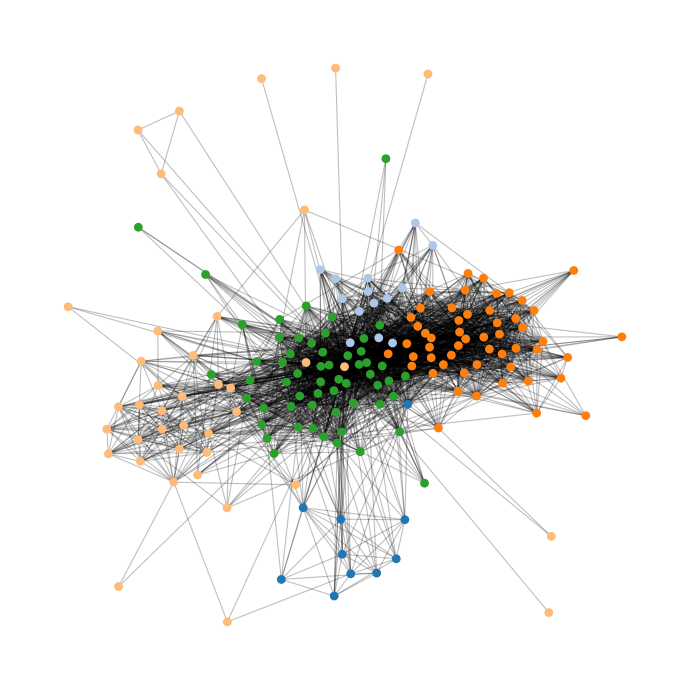

In [15]:
pos = nx.spring_layout(M, seed=1)  # compute once, reuse across panels

cmap = colormaps["tab20"]
node_colors = [cmap(module_of[n] % 20) for n in M.nodes()]

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(M, pos, alpha=0.25, width=0.8)
nx.draw_networkx_nodes(M, pos, node_color=node_colors, node_size=40, linewidths=0)
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
modules = {i: sorted(list(nodes)) for i, nodes in enumerate(comms)}

# pd.set_option('display.max_colwidth', None)

database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

for module, nodes in modules.items():
    
    print(f"Module {module+1}: {len(nodes)} genes")

    enr = gget.enrichr(
        nodes,
        database,
        save=False,
    )

    enr = enr[enr['adj_p_val'] < 0.05]
    print(enr.columns)

    enr['adj_score'] = abs(np.log(enr['adj_p_val']) * enr['z_score'])
        
    # enr = enr.sort_values(by='adj_score', ascending=False)
    
    display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score', 'adj_score']].head(10))
    
    # break

Fri Apr 17 12:01:26 2026 INFO Performing Enichr analysis using database GO_Biological_Process_2025.


Module 1: 10 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Reg of Cardiac Muscle Cell Action Potential Inv in Reg of Contraction (GO:0098909),"[HCN4, CAV1]",0.001180,999.250000,12254.800453,6737.480631
1,Positive Regulation of Dendritic Spine Development (GO:0060999),"[CUX2, NEURL1]",0.005279,237.726190,2324.813163,1246.643797
2,Regulation of Cardiac Muscle Cell Contraction (GO:0086004),"[HCN4, CAV1]",0.005279,207.979167,1981.986469,1090.649446
3,Regulation of Cardiac Muscle Cell Action Potential (GO:0098901),"[HCN4, CAV1]",0.005279,191.961538,1800.445422,1006.652488
4,Regulation of Heart Rate by Cardiac Conduction (GO:0086091),"[HCN4, CAV1]",0.009130,127.891026,1100.917922,600.605287
5,Cardiac Conduction (GO:0061337),"[HCN4, CAV1]",0.010014,110.805556,923.399314,510.127673
6,Positive Regulation of Neurogenesis (GO:0050769),"[CUX2, NEURL1]",0.014382,80.354839,619.922544,340.849759
7,Positive Regulation of Cell Junction Assembly (GO:1901890),"[CUX2, CAV1]",0.014382,79.075397,607.601661,335.422613
8,Potassium Ion Transport (GO:0006813),"[HCN4, KCNN3]",0.034597,39.730000,252.411159,133.651448
9,Potassium Ion Transmembrane Transport (GO:0071805),"[HCN4, KCNN3]",0.034597,37.609848,234.960394,126.519273


Fri Apr 17 12:01:26 2026 INFO Performing Enichr analysis using database GO_Biological_Process_2025.


Module 2: 14 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


...

Module 4: 39 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Regulation of Transcription by RNA Polymerase II (GO:0006357),"[PRRX1, OSR1, ARID5B, PSIP1, HOXD13, HOXC13, HOXB13, HOXD11, ETV6, MEIS1, HOXA9, TAL1, KAT6A, NSD1, MYC, HOXC4, HOXA7, GTF2I]",0.000009,6.808372,114.872103,79.175647
1,Positive Regulation of DNA-templated Transcription (GO:0045893),"[PRRX1, OSR1, PSIP1, HOXD13, HOXC13, NSD3, MEIS1, TAL1, KAT6A, NSD1, MYC, HOXC4, HOXA7, GTF2I]",0.000009,8.311556,138.734453,96.656413
2,Embryonic Skeletal System Morphogenesis (GO:0048704),"[HOXA9, OSR1, HOXC4, HOXD11]",0.000051,78.549754,1142.067853,776.251445
3,Regulation of DNA-templated Transcription (GO:0006355),"[PRRX1, ARID5B, HOXD13, HOXC13, HOXB13, HOXD11, ETV6, NSD3, HOXA9, SETBP1, TAL1, KAT6A, NSD1, MYC, HOXA7]",0.000425,5.248646,63.682376,40.748689
4,Positive Regulation of Transcription by RNA Polymerase II (GO:0045944),"[MEIS1, PRRX1, TAL1, OSR1, MYC, PSIP1, HOXC4, HOXD13, HOXA7, GTF2I]",0.000857,6.729277,75.420781,47.519152
5,Hemopoiesis (GO:0030097),"[MEIS1, TAL1, KAT6A, ETV6]",0.002317,23.403829,234.777814,142.005439
6,Embryonic Skeletal System Development (GO:0048706),"[HOXA9, OSR1, HOXC4]",0.002908,44.873874,433.031543,262.069619
7,Embryonic Skeletal Joint Morphogenesis (GO:0060272),"[OSR1, HOXD11]",0.003054,215.740541,2042.516553,1249.389459
8,Embryonic Skeletal Joint Development (GO:0072498),"[OSR1, HOXD11]",0.003616,179.774775,1650.515154,1010.783448
9,Anterior/Posterior Pattern Specification (GO:0009952),"[HOXA9, HOXC4, HOXA7]",0.008703,26.745968,219.244008,126.885979


Fri Apr 17 12:01:27 2026 INFO Performing Enichr analysis using database GO_Biological_Process_2025.


Module 5: 57 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Regulation of Transcription by RNA Polymerase II (GO:0006357),"[IHH, SIX1, MEOX2, FOXM1, GLI1, HOXA13, GLI3, SOX2, SHH, HHEX, SOX9, PITX2, SOX4, ZNF366, OSR2, FOXD1, MSX2, WNT5A, SOX10, POU5F1, ZEB2, ZEB1, HAND2, PAX9, FOXC2, FOXC1, SRF, TWIST2, TWIST1, GLIS1, MSX1, IRX1, FOXF2, IRX6, FOXF1, IRX3, KLF4, TBX5, MEIS2, TBX4, TBX18, TBX3, TBX2, BMP4, KLF8, TBX15, SNAI1, SNAI2, CTNNB1, FOXA2]",2.355062e-37,57.607143,5250.271881,4858.533513
1,Regulation of DNA-templated Transcription (GO:0006355),"[FOXC2, FOXC1, TWIST2, SIX1, TWIST1, MEOX2, FOXM1, GLI1, HOXA13, GLIS1, GLI3, SOX2, SHH, HHEX, MSX1, SOX9, PITX2, SOX4, FZD1, IRX1, OSR2, FOXD1, MSX2, FOXF2, IRX6, FOXF1, IRX3, WNT5A, KLF4, TBX5, SOX10, TBX4, POU5F1, TBX18, TBX3, TBX2, BMP4, KLF8, TBX15, ZEB2, ZEB1, HAND2, PAX9, SNAI1, SNAI2, CTNNB1, FOXA2]",9.763844e-34,40.105019,3293.272969,3048.350699
2,Negative Regulation of DNA-templated Transcription (GO:0045892),"[FOXC2, FOXC1, SRF, TWIST2, TWIST1, FOXM1, GLIS1, GLI3, SOX2, SHH, HHEX, SOX9, PITX2, SOX4, ZNF366, IRX1, OSR2, FOXD1, MSX2, IRX3, WNT5A, KLF4, SOX10, MEIS2, POU5F1, TBX18, TBX3, TBX2, BMP4, KLF8, ZEB2, ZEB1, PAX9, SNAI1, SNAI2, CTNNB1, FOXA2]",6.586094e-32,36.224871,2807.402878,2600.864683
3,Negative Regulation of Transcription by RNA Polymerase II (GO:0000122),"[FOXC2, FOXC1, TWIST1, FOXM1, GLIS1, GLI3, SOX2, SHH, HHEX, SOX9, PITX2, SOX4, ZNF366, IRX1, OSR2, MSX2, IRX3, KLF4, SOX10, MEIS2, POU5F1, TBX18, TBX3, TBX2, BMP4, KLF8, ZEB2, ZEB1, SNAI1, SNAI2, FOXA2]",1.757339e-27,32.728081,2193.431792,2016.246031
4,Positive Regulation of DNA-templated Transcription (GO:0045893),"[FOXC2, FOXC1, SRF, IHH, SIX1, TWIST1, MEOX2, FOXM1, GLI1, GLIS1, GLI3, SOX2, SHH, HHEX, SOX9, PITX2, SOX4, FZD1, OSR2, FOXF2, IRX6, FOXF1, IRX3, WNT5A, KLF4, TBX5, SOX10, MEIS2, POU5F1, TBX3, BMP4, ZEB2, HAND2, SNAI1, CTNNB1, FOXA2]",5.762653e-27,25.901223,1699.356761,1564.910449
5,Positive Regulation of Transcription by RNA Polymerase II (GO:0045944),"[FOXC2, FOXC1, SRF, IHH, SIX1, TWIST1, MEOX2, FOXM1, GLI1, GLIS1, GLI3, SOX2, SHH, HHEX, SOX9, PITX2, SOX4, OSR2, FOXF2, FOXF1, IRX3, WNT5A, KLF4, TBX5, MEIS2, POU5F1, TBX3, BMP4, ZEB2, HAND2, CTNNB1, FOXA2]",3.766103e-25,25.562313,1565.614933,1437.588372
6,Positive Regulation of RNA Biosynthetic Process (GO:1902680),"[FZD1, OSR2, FOXC2, FOXC1, FOXF2, IRX6, FOXF1, WNT5A, SIX1, KLF4, TBX5, FOXM1, GLI1, SOX10, GLI3, BMP4, SOX2, SHH, HHEX, SNAI1, CTNNB1, SOX9, SOX4, FOXA2]",1.093219e-20,26.587228,1351.078788,1222.017472
7,Embryonic Limb Morphogenesis (GO:0030326),"[OSR2, SHH, IHH, TWIST1, CTNNB1, TBX5, TBX4, GLI3, TBX3, TBX2]",4.136082e-16,162.986907,6542.676010,5773.259070
8,Neuron Differentiation (GO:0030182),"[FZD1, IRX1, IRX6, IRX3, SRF, WNT5A, SOX2, SHH, FGF8, HAND2, CTNNB1, PITX2, SOX4, FOXA2]",8.123819e-15,38.555076,1428.346872,1250.879960
9,Embryonic Digit Morphogenesis (GO:0042733),"[OSR2, SHH, IHH, TWIST1, MSX1, GLI3, TBX3, TBX2]",1.001355e-14,325.436735,11954.079516,10490.400147
